# Classification

## imports and format

In [1]:
import pandas as pd
import numpy as np
import math
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
#expanding column width
pd.set_option('display.max_colwidth', None)

In [3]:

df = pd.read_pickle('/Users/isishassan/Documents/Ironhack/FinalProject/df.pkl')

In [4]:
#sign map
sign_map = {
    "aries": 1,
    "taurus": 2,
    "gemini": 3,
    "cancer": 4,
    "leo": 5,
    "virgo": 6,
    "libra": 7,
    "scorpio": 8,
    "sagittarius": 9,
    "capricorn": 10,
    "aquarius": 11,
    "pisces": 12
}

In [ ]:
#elements
element_map = {
    "aries": "Fire",
    "leo": "Fire",
    "sagittarius": "Fire",
    
    "taurus": "Earth",
    "virgo": "Earth",
    "capricorn": "Earth",
    
    "gemini": "Air",
    "libra": "Air",
    "aquarius": "Air",
    
    "cancer": "Water",
    "scorpio": "Water",
    "pisces": "Water"
}

element_colors = {
    "Fire": "red",
    "Earth": "green",
    "Air": "lightblue",
    "Water": "blue"
}

## Data prep

- drop unnecessary columns
- split into train/test

In [6]:
X = df["horoscope"]
y = df["sign_id"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42, test_size = 0.20,stratify=y) 

## Various Classifiers: Custom Stopwords Removed

using TF-IDF
getting baseline before deciding which one to tune

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
from nltk.corpus import stopwords

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, f1_score, classification_report

# 0. custom stopwords

stop_words = set(stopwords.words("english"))
custom_stopwords = ["Sign","Name","time","today","year","may","could","get","work","make","people","take","love","good","feel","new","things","need","life","sign","name","might","find"]
stop_words.update(custom_stopwords)



# 1. Define models
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=200,C=0.3,verbose=1),
    "Linear SVM": LinearSVC(),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42,verbose=1)
}


# 2. Training + evaluation loop
results = []

for name, clf in models.items():

    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(
            stop_words=list(stop_words),
            ngram_range=(1,2),
            max_features=10000,
            min_df=3,                       #absolute: 3 occurences
            max_df=0.9                       #relative: fraction    
        )),
        ("model", clf)
    ],verbose=True)

    # train
    pipeline.fit(X_train, y_train)

    # predictions
    train_pred = pipeline.predict(X_train)
    test_pred = pipeline.predict(X_test)

    # metrics
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    train_f1 = f1_score(y_train, train_pred, average="macro")
    test_f1 = f1_score(y_test, test_pred, average="macro")

    results.append({
        "model": name,
        "train_accuracy": train_acc,
        "test_accuracy": test_acc,
        "train_f1_macro": train_f1,
        "test_f1_macro": test_f1
    })


# 3. Results
results_df = pd.DataFrame(results)
print(results_df)

[Pipeline] ............. (step 1 of 2) Processing tfidf, total=   9.1s
[Pipeline] ............. (step 2 of 2) Processing model, total=   0.5s
[Pipeline] ............. (step 1 of 2) Processing tfidf, total=  13.8s
[Pipeline] ............. (step 2 of 2) Processing model, total=   6.4s
[Pipeline] ............. (step 1 of 2) Processing tfidf, total=   6.9s
[Pipeline] ............. (step 2 of 2) Processing model, total=  12.1s
[Pipeline] ............. (step 1 of 2) Processing tfidf, total=   6.4s


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:   51.1s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:  3.4min
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:  3.5min finished


[Pipeline] ............. (step 2 of 2) Processing model, total= 3.5min


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    6.2s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:   31.6s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:   32.0s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    7.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:   37.8s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:   38.5s finished


                 model  train_accuracy  test_accuracy  train_f1_macro  \
0          Naive Bayes        0.573353       0.046094        0.573355   
1  Logistic Regression        0.458009       0.054475        0.457906   
2           Linear SVM        0.906512       0.057468        0.906501   
3        Random Forest        0.999925       0.058066        0.999925   

   test_f1_macro  
0       0.045795  
1       0.054079  
2       0.057392  
3       0.058032  


### Confusion Matrix: RandomForest

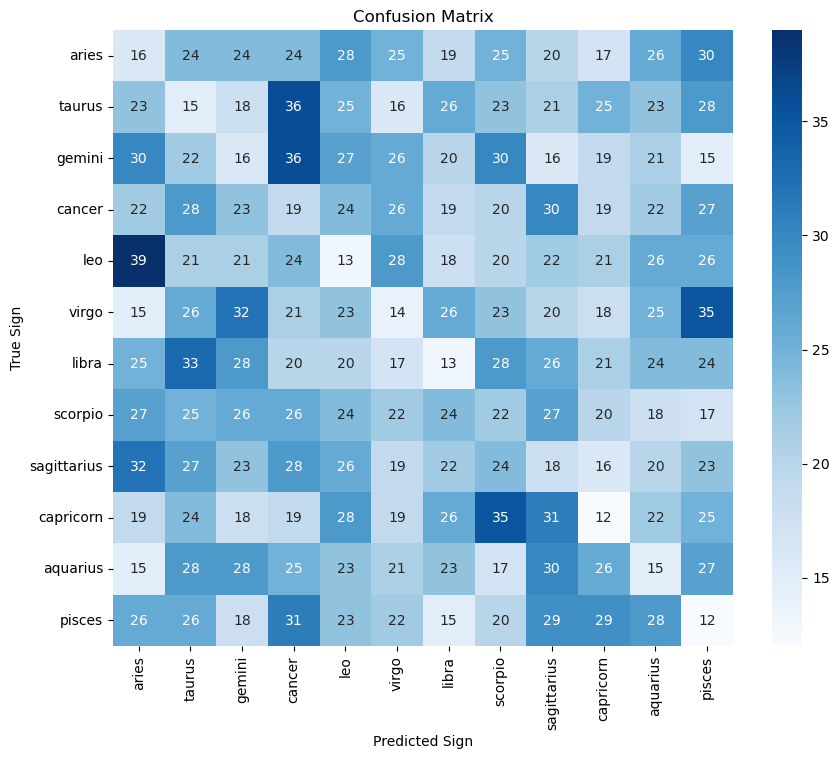

In [ ]:
id_to_sign = {v: k for k, v in sign_map.items()}
labels = list(range(1, 13))                         #so it starts with 1
label_names = [id_to_sign[i] for i in labels]

cm = confusion_matrix(
    y_test,
    test_pred,
    labels=labels
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_names,
    yticklabels=label_names,
    cmap="Blues"
)

plt.xlabel("Predicted Sign")
plt.ylabel("True Sign")
plt.title("Confusion Matrix")

plt.show()

### Trying to reduce overfitting

In [34]:
# 0. custom stopwords

stop_words = set(stopwords.words("english"))
custom_stopwords = ["time","today","year","may","could","get","work","make","people","take","love","good","feel","new","things","need","life","sign","name","might","find"]
stop_words.update(custom_stopwords)


# 1. Define models
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=200,C =0.5,verbose=1),       #multiple Cs
    "Linear SVM": LinearSVC(C=0.5),                                                                     #setting a C
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42,verbose=1)
}


# 2. Training + evaluation loop
results = []

for name, clf in models.items():

    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(
            stop_words=list(stop_words),
            token_pattern=r'\b[a-zA-Z]{3,}\b',      #removes super short words   
            ngram_range=(1,1),              #reduced to 1,1
            max_features=5000,              #reduced to 5k    
            min_df=5,                       #increased to 5
            max_df=0.5                      #reduced to 0.85   
        )),
        ("model", clf)
    ],verbose=True)

    # train
    pipeline.fit(X_train, y_train)

    # predictions
    train_pred = pipeline.predict(X_train)
    test_pred = pipeline.predict(X_test)

    # metrics
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    train_f1 = f1_score(y_train, train_pred, average="macro")
    test_f1 = f1_score(y_test, test_pred, average="macro")

    results.append({
        "model": name,
        "train_accuracy": train_acc,
        "test_accuracy": test_acc,
        "train_f1_macro": train_f1,
        "test_f1_macro": test_f1
    })


# 3. Results
results_df = pd.DataFrame(results)
print(results_df)

[Pipeline] ............. (step 1 of 2) Processing tfidf, total=   1.9s
[Pipeline] ............. (step 2 of 2) Processing model, total=   0.1s
[Pipeline] ............. (step 1 of 2) Processing tfidf, total=   1.2s


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.4s finished


[Pipeline] ............. (step 2 of 2) Processing model, total=   3.4s
[Pipeline] ............. (step 1 of 2) Processing tfidf, total=   1.1s
[Pipeline] ............. (step 2 of 2) Processing model, total=   4.1s
[Pipeline] ............. (step 1 of 2) Processing tfidf, total=   1.1s


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:   21.3s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:  1.0min
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:  1.0min finished


[Pipeline] ............. (step 2 of 2) Processing model, total= 1.0min


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.7s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    2.1s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:    2.1s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.5s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:    0.5s finished


                 model  train_accuracy  test_accuracy  train_f1_macro  \
0          Naive Bayes        0.470135       0.053577        0.470099   
1  Logistic Regression        0.418039       0.061359        0.417920   
2           Linear SVM        0.653817       0.054475        0.653733   
3        Random Forest        0.999925       0.070937        0.999925   

   test_f1_macro  
0       0.053118  
1       0.060917  
2       0.054268  
3       0.070620  


Note: reduced overfitting gap

In [36]:
X_vec = pipeline.named_steps["tfidf"].transform(X_train)

print(X_vec.shape)

(13360, 5000)


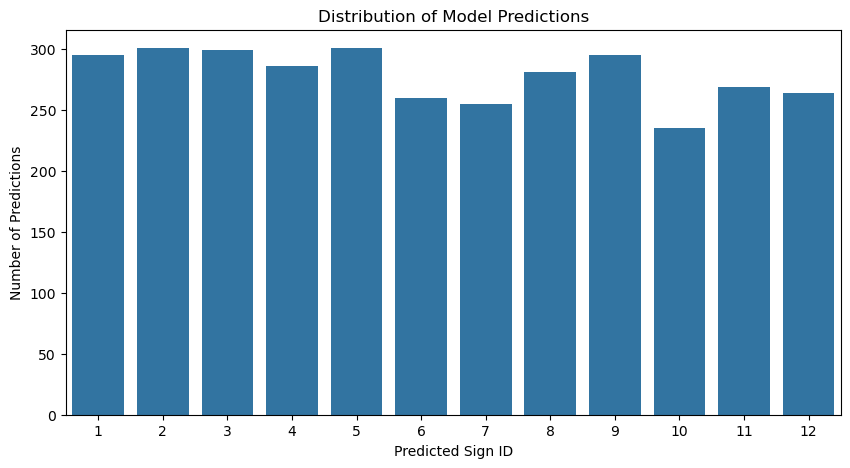

In [ ]:
#is my model collapsing?

pred_counts = pd.Series(test_pred).value_counts().sort_index()

plt.figure(figsize=(10,5))

sns.barplot(
    x=pred_counts.index,
    y=pred_counts.values
)

plt.xlabel("Predicted Sign ID")
plt.ylabel("Number of Predictions")
plt.title("Distribution of Model Predictions")

plt.show()

#A: no

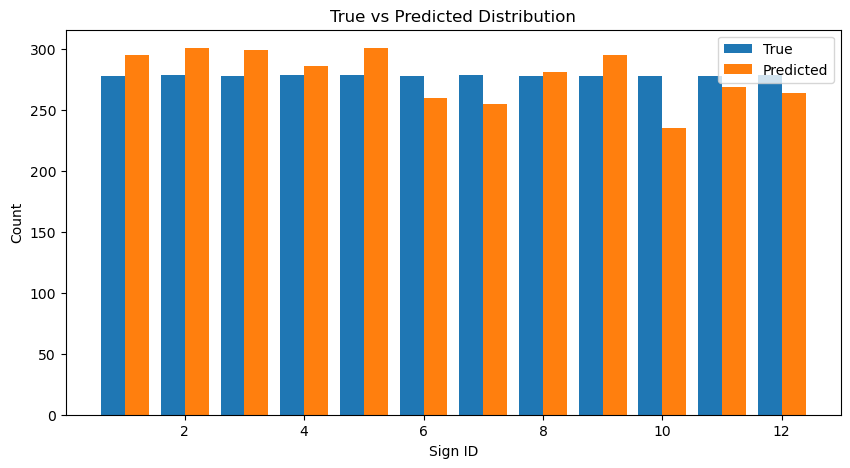

In [39]:
true_counts = pd.Series(y_test).value_counts().sort_index()

plt.figure(figsize=(10,5))

plt.bar(true_counts.index - 0.2, true_counts.values, width=0.4, label="True")
plt.bar(pred_counts.index + 0.2, pred_counts.values, width=0.4, label="Predicted")

plt.xlabel("Sign ID")
plt.ylabel("Count")
plt.title("True vs Predicted Distribution")
plt.legend()

plt.show()

### Chunking horoscopes together

In [40]:
def create_chunks(df, chunk_size=10):
    
    chunk_texts = []
    chunk_labels = []

    for sign_id, group in df.groupby("sign_id"):
        
        texts = group["horoscope"].tolist()
        
        # create chunks
        for i in range(0, len(texts), chunk_size):
            chunk = texts[i:i+chunk_size]
            
            # only keep full chunks
            if len(chunk) == chunk_size:
                chunk_texts.append(" ".join(chunk))
                chunk_labels.append(sign_id)

    return pd.DataFrame({
        "text": chunk_texts,
        "sign_id": chunk_labels
    })

In [46]:
#chunk size = 10
df_chunks = create_chunks(df, chunk_size=5)

In [47]:
X_ch10 = df_chunks["text"]
y_ch10 = df_chunks["sign_id"]

X_train_ch10, X_test_ch10, y_train_ch10, y_test_ch10 = train_test_split(
    X_ch10,
    y_ch10,
    test_size=0.2,
    stratify=y_ch10,
    random_state=42
)

In [49]:
#pipeline

# 0. custom stopwords

stop_words = set(stopwords.words("english"))
custom_stopwords = ["time","today","year","may","could","get","work","make","people","take","love","good","feel","new","things","need","life","sign","name","might","find"]
stop_words.update(custom_stopwords)


# 1. Define models
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=200,C =0.5,verbose=1),       #multiple Cs
    "Linear SVM": LinearSVC(C=0.5),                                                                     #setting a C
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42,verbose=1)
}


# 2. Training + evaluation loop
results = []

for name, clf in models.items():

    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(
            stop_words=list(stop_words),
            token_pattern=r'\b[a-zA-Z]{3,}\b',      #removes super short words   
            ngram_range=(1,2),              #doing bigrams
            max_features=8000,              #reduced to 5k    
            min_df=5,                       #increased to 5
            max_df=0.5                      #reduced to 0.85   
        )),
        ("model", clf)
    ],verbose=True)

    # train
    pipeline.fit(X_train_ch10, y_train_ch10)

    # predictions
    train_pred_ch = pipeline.predict(X_train_ch10)
    test_pred_ch = pipeline.predict(X_test_ch10)

    # metrics
    train_acc = accuracy_score(y_train_ch10, train_pred_ch)
    test_acc = accuracy_score(y_test_ch10, test_pred_ch)

    train_f1 = f1_score(y_train_ch10, train_pred_ch, average="macro")
    test_f1 = f1_score(y_test_ch10, test_pred_ch, average="macro")

    results.append({
        "model": name,
        "train_accuracy": train_acc,
        "test_accuracy": test_acc,
        "train_f1_macro": train_f1,
        "test_f1_macro": test_f1
    })


# 3. Results
results_df = pd.DataFrame(results)
print(results_df)

[Pipeline] ............. (step 1 of 2) Processing tfidf, total=  13.2s
[Pipeline] ............. (step 2 of 2) Processing model, total=   0.1s
[Pipeline] ............. (step 1 of 2) Processing tfidf, total=   7.1s


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    2.4s finished


[Pipeline] ............. (step 2 of 2) Processing model, total=   2.5s
[Pipeline] ............. (step 1 of 2) Processing tfidf, total=   5.9s
[Pipeline] ............. (step 2 of 2) Processing model, total=   1.6s
[Pipeline] ............. (step 1 of 2) Processing tfidf, total=   3.0s


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    7.5s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:   28.9s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:   29.1s finished


[Pipeline] ............. (step 2 of 2) Processing model, total=  29.2s


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.5s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    2.2s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:    2.2s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:    0.2s finished


                 model  train_accuracy  test_accuracy  train_f1_macro  \
0          Naive Bayes        0.871016       0.029985        0.871603   
1  Logistic Regression        0.881515       0.032984        0.881700   
2           Linear SVM        0.997750       0.040480        0.997749   
3        Random Forest        1.000000       0.049475        1.000000   

   test_f1_macro  
0       0.030807  
1       0.032549  
2       0.040022  
3       0.049004  


Note: Chunking made performance even worse

### Larger ngram range (3-5), Linear SVC

In [ ]:
vectorizer = TfidfVectorizer(
    analyzer="char",
    stop_words=list(stop_words),
    token_pattern=r'\b[a-zA-Z]{3,}\b',      #removes super short words   
    ngram_range=(3,5),
    min_df=3,
    max_features=20000
)

In [56]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="char",
        ngram_range=(3,5),
        min_df=3,
        max_features=20000
    )),
    ("model", LinearSVC(C=1))
])

pipeline.fit(X_train, y_train)

,steps,"[('tfidf', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [57]:
# predictions
train_pred = pipeline.predict(X_train)
test_pred = pipeline.predict(X_test)

    # metrics
train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

train_f1 = f1_score(y_train, train_pred, average="macro")
test_f1 = f1_score(y_test, test_pred, average="macro")

results.append({
    "model": name,
    "train_accuracy": train_acc,
    "test_accuracy": test_acc,
    "train_f1_macro": train_f1,
    "test_f1_macro": test_f1
})


# 3. Results
results_df = pd.DataFrame(results)
print(results_df)

                 model  train_accuracy  test_accuracy  train_f1_macro  \
0          Naive Bayes        0.871016       0.029985        0.871603   
1  Logistic Regression        0.881515       0.032984        0.881700   
2           Linear SVM        0.997750       0.040480        0.997749   
3        Random Forest        1.000000       0.049475        1.000000   
4        Random Forest        0.807784       0.052978        0.807807   
5        Random Forest        0.807784       0.052978        0.807807   

   test_f1_macro  
0       0.030807  
1       0.032549  
2       0.040022  
3       0.049004  
4       0.053116  
5       0.053116  


Note: No improvement

## Various Classifiers: no custom stopwords

In [ ]:
# 1. Define models
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=200,C =0.3,verbose=1),       #multiple Cs
    "Linear SVM": LinearSVC(C=0.1),                                                  #lower C
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42,verbose=1)
}


# 2. Training + evaluation loop
results = []

all_preds = {}

for name, clf in models.items():

    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(
            stop_words="english",                   #no custom stopwrods
            token_pattern=r'\b[a-zA-Z]{3,}\b',      #removes super short words   
            ngram_range=(1,1),              #reduced to 1,1
            max_features=10000,                 
            min_df=10,                       #increased to 5
            max_df=0.9                      #reduced to 0.85   
        )),
        ("model", clf)
    ],verbose=True)

    all_preds[name] = {
        "train_pred": train_pred,
        "test_pred": test_pred
    }

    # train
    pipeline.fit(X_train, y_train)

    # predictions
    train_pred = pipeline.predict(X_train)
    test_pred = pipeline.predict(X_test)

    # metrics
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    train_f1 = f1_score(y_train, train_pred, average="macro")
    test_f1 = f1_score(y_test, test_pred, average="macro")

    results.append({
        "model": name,
        "train_accuracy": train_acc,
        "test_accuracy": test_acc,
        "train_f1_macro": train_f1,
        "test_f1_macro": test_f1
    })


# 3. Results
results_df = pd.DataFrame(results)
print(results_df)

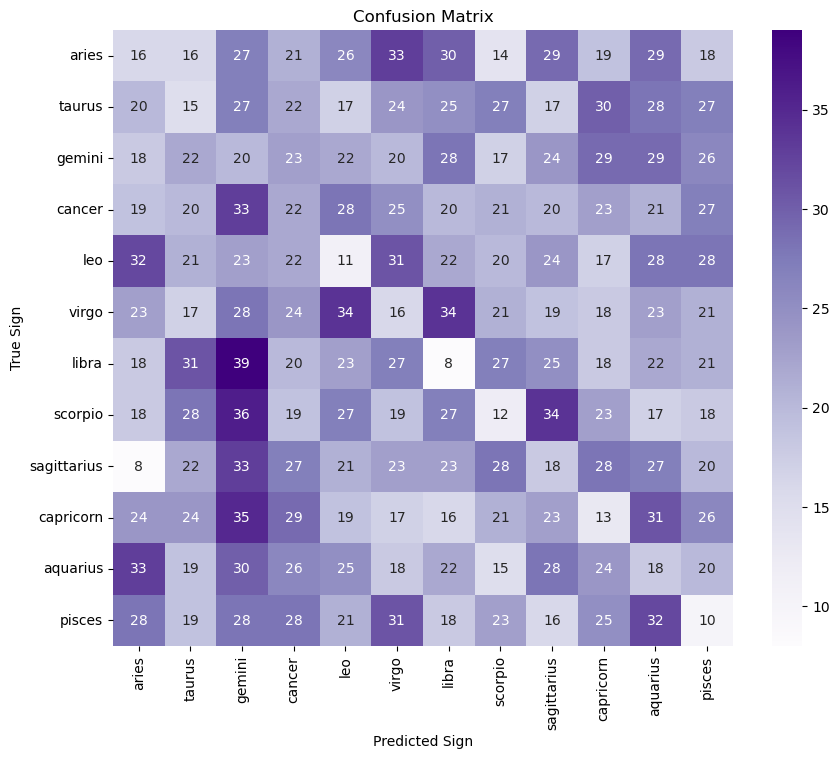

In [ ]:

model_name = "Logistic Regression"
test_pred = all_preds[model_name]["test_pred"]

id_to_sign = {v: k for k, v in sign_map.items()}    #sign_map contains my sign to sign_id mapping,eg areis = 1
labels = list(range(1, 13))                         #so it starts with 1
label_names = [id_to_sign[i] for i in labels]

cm = confusion_matrix(
    y_test,
    test_pred,
    labels=labels
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_names,
    yticklabels=label_names,
    cmap="Purples"
)

plt.xlabel("Predicted Sign")
plt.ylabel("True Sign")
plt.title("Confusion Matrix")

plt.show()

### Hyperparameter Tuning

In [ ]:
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.calibration import CalibratedClassifierCV


stop_words = set(stopwords.words("english"))

#1 Shared TF-IDF (fit once, reuse)
tfidf = TfidfVectorizer(
    stop_words=list(stop_words),
    ngram_range=(1, 1),  
    max_features=5000,
    min_df=10,            
    max_df=0.85
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)


#2 GridSearch on LogReg
lr = LogisticRegression(max_iter=1000, solver="saga", multi_class="multinomial")

lr_grid = GridSearchCV(
    lr,
    param_grid={"C": [0.01, 0.05, 0.1, 0.3, 1.0]},          
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)
lr_grid.fit(X_train_tfidf, y_train)
print("Best LR C:", lr_grid.best_params_, "| CV F1:", lr_grid.best_score_)
best_lr = lr_grid.best_estimator_


#3 GridSearch on LinearSVC
# LinearSVC has no predict_proba, wrap it for voting ensemble later
svc = CalibratedClassifierCV(LinearSVC(max_iter=2000), cv=3)

svc_grid = GridSearchCV(
    svc,
    param_grid={"estimator__C": [0.01, 0.05, 0.1, 0.5, 1.0]},  # estimator__ prefix
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)
svc_grid.fit(X_train_tfidf, y_train)
print("Best SVC C:", svc_grid.best_params_, "| CV F1:", svc_grid.best_score_)
best_svc = svc_grid.best_estimator_


#4 Soft Voting Ensemble
ensemble = VotingClassifier(
    estimators=[
        ("lr",  best_lr),
        ("svc", best_svc),
    ],
    voting="soft"   # uses predicted probabilities — generally better than hard
)
ensemble.fit(X_train_tfidf, y_train)


#5. Evaluate all three
for label, model in [("LogReg", best_lr), ("LinearSVC", best_svc), ("Ensemble", ensemble)]:
    test_pred  = model.predict(X_test_tfidf)
    train_pred = model.predict(X_train_tfidf)
    print(f"\n{label}")
    print(f"  Train acc: {accuracy_score(y_train, train_pred):.3f}")
    print(f"  Test  acc: {accuracy_score(y_test,  test_pred):.3f}")
    print(f"  Test  F1:  {f1_score(y_test, test_pred, average='macro'):.3f}")

Fitting 5 folds for each of 5 candidates, totalling 25 fits


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in ve

Best LR C: {'C': 0.01} | CV F1: 0.05911363847883425
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best SVC C: {'estimator__C': 0.5} | CV F1: 0.1216311631178548


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



LogReg
  Train acc: 0.312
  Test  acc: 0.057
  Test  F1:  0.055

LinearSVC
  Train acc: 0.002
  Test  acc: 0.139
  Test  F1:  0.137

Ensemble
  Train acc: 0.002
  Test  acc: 0.140
  Test  F1:  0.138


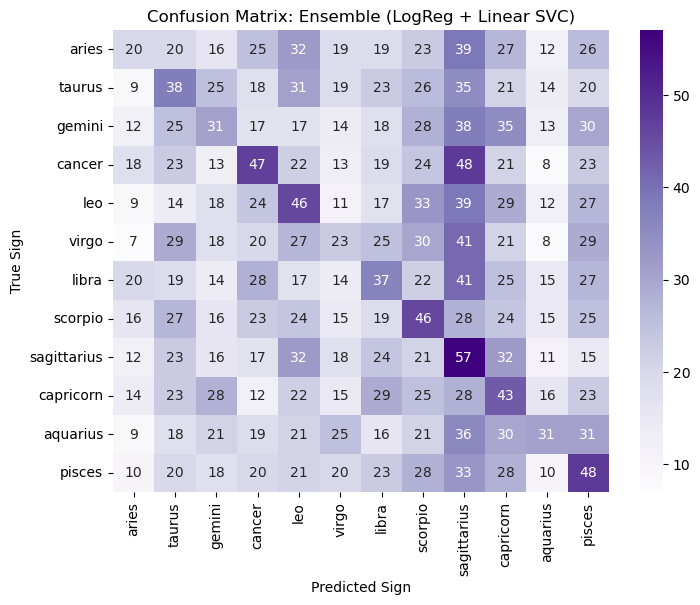

In [ ]:
from sklearn.metrics import confusion_matrix

#model_name = "ensemble"
#test_pred = all_preds[model_name]["test_pred"]

id_to_sign = {v: k for k, v in sign_map.items()}    #sign_map contains my sign to sign_id mapping,eg areis = 1
labels = list(range(1, 13))                         #so it starts with 1
label_names = [id_to_sign[i] for i in labels]

cm = confusion_matrix(
    y_test,
    test_pred,
    labels=labels
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_names,
    yticklabels=label_names,
    cmap="Purples"
)

plt.xlabel("Predicted Sign")
plt.ylabel("True Sign")
plt.title("Confusion Matrix: Ensemble (LogReg + Linear SVC)")

plt.show()